# Now the training

In [11]:
# Importing the whole model architecture and text generator

import torch
import tiktoken
import torch.nn as nn
from ModelARC import GPT_Model
from ModelARC import generate_text_simple


print("test")
# redifining the GPT config
GPT_CONFIG_124M ={

    "vocab_size" : 50257, #Vocabulary size for GPT2
    "context_length" : 256, # Context Length is shorter for ease in training
    "emb_dim":768, # Embedding Dimension
    "n_heads":12, # 12 attention heads
    "n_layers":12, # Number of layers
    "drop_rate":0.1, #Dropout rate
    "qkv_bias": False #Query,key,value bias

}
torch.manual_seed(123)
model=GPT_Model(GPT_CONFIG_124M)
model.eval()

# text generation, along with two new functions for easy text to id and id to text conversion

tokenizer= tiktoken.get_encoding("gpt2")

def text_to_token_ids(text,tokenizer):
    encoded=tokenizer.encode(text,allowed_special={'<|endoftext|>'})
    encoded_tensor=torch.tensor(encoded).unsqueeze(0) # adds the batch dim
    return encoded_tensor

def token_ids_to_text(token_ids,tokenizer):
    flat_ids=token_ids.squeeze(0)
    return tokenizer.decode(flat_ids.tolist())

start_context="Every effort moves you"

token_ids=generate_text_simple(model=model,idx=text_to_token_ids(start_context,tokenizer),
                               max_new_tokens=10,context_size=GPT_CONFIG_124M["context_length"])

output_text=token_ids_to_text(token_ids,tokenizer)
print("Output: ", output_text)


test
Output:  Every effort moves you Laur inhab Distrine bribes manufacture KentuckyHel revolvesNic


# training example

In [12]:
# we will create 2 sampl ibnpts and targets
inputs=torch.tensor([[16833,3626,6100], #every effort moves
                    [40,1107,588]]) #I really like


# now targets
targets=torch.tensor([[3626, 6100, 345], # effort moves you
                    [1107, 588, 11311]]) # really like chocolate

i1=token_ids_to_text(inputs[0],tokenizer)
print(i1)
i2=token_ids_to_text(inputs[1],tokenizer)
print(i2)
t1=token_ids_to_text(targets[0],tokenizer)
print(t1)
t2=token_ids_to_text(targets[1],tokenizer)
print(t2)

# now we will feed these inputs into the model to calculate the logits, and then we will aplly the softmax to 
# transform these logits to probability scores
torch.manual_seed(123)

with torch.no_grad(): # we arent training yet so grad is disabled
    logits=model(inputs)

probas=torch.softmax(logits,dim=-1)
print(probas.shape)

token_ids=torch.argmax(probas,dim=-1,keepdim=True)
print("\nOutput target: ",token_ids)

# now printing both batches
print(f"Targets batch 1: {token_ids_to_text(targets[0],tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(),tokenizer)}")




every effort moves
I really like
 effort moves you
 really like chocolate
torch.Size([2, 3, 50257])

Output target:  tensor([[[43756],
         [16031],
         [42826]],

        [[48671],
         [16031],
         [37306]]])
Targets batch 1:  effort moves you
Outputs batch 1:  dw savesNetflix


In [13]:
# we will evaluate the output from the targets

text_idx=0
target_probas_1=probas[text_idx,[0,1,2],targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx=1
target_probas_2=probas[text_idx,[0,1,2],targets[text_idx]]
print("Text 2:", target_probas_2)


Text 1: tensor([4.8458e-05, 2.2225e-05, 1.2137e-05])
Text 2: tensor([1.2687e-05, 3.6101e-05, 4.5523e-06])


# D unk : Trying to calculate loss

In [14]:
# now we will apply log to get the loss for the probability scores (how far off was the model from correct guess)

log_probas=torch.log(torch.cat((target_probas_1,target_probas_2)))
print(log_probas)

#average
avg_log_probas=torch.mean(log_probas)
print(avg_log_probas)

# since in ML, the loss is decreased down to zero as convetion, we can just multiply by -1 to get neg log
# and then through backpropagation we will try to get a 0 or close loss

neg_avg_log_probas=avg_log_probas*-1
print(neg_avg_log_probas)

# this whole process is called cross entropy loss, and python has a built in function

# before implemennting this function, recalling shapes of logits and targets

print("Logits Shape: ", logits.shape)
print("Targets Shape: ",targets.shape)

# these are [2,3,50257] in shape, the 2 is batch dim and 3 being num_tokens, for cross_entropy function 
# we have to flatten these

logits_flat=logits.flatten(0,1) # over dim - and 1, leaving the 50257 emb vocab dim
targets_flat=targets.flatten() # no emb dim

print("Flat Logits Shape: ", logits_flat.shape)
print("Flat Targets Shape: ",targets_flat.shape)

# previously we did 6 steps, applied softmax,selected prob scores correspending to targets and computed neg log 
# probas, this cross_entropy function does it all for us
loss=torch.nn.functional.cross_entropy(logits_flat,targets_flat)
print("Cross Entropy: ",loss)

# we can also check preplexity, which is effective vocab size about which the model is uncertain to pick from
#lower is better
preplexity=torch.exp(loss)
print("Preplexity: ",preplexity)

tensor([ -9.9348, -10.7143, -11.3192, -11.2750, -10.2292, -12.2999])
tensor(-10.9621)
tensor(10.9621)
Logits Shape:  torch.Size([2, 3, 50257])
Targets Shape:  torch.Size([2, 3])
Flat Logits Shape:  torch.Size([6, 50257])
Flat Targets Shape:  torch.Size([6])
Cross Entropy:  tensor(10.9621)
Preplexity:  tensor(57645.2344)


# applying loss calculation to the entire dataset

In [15]:
#loading the dataset "The verdict"
file_path="the-verdict.txt"
with open(file_path,"r",encoding='utf-8') as file:
    text_data=file.read()

#chexking features
total_char=len(text_data)
total_tokens=len(tokenizer.encode(text_data))

print("Total Char: ", total_char)
print("Total Tokens: ",total_tokens)


# we split the datasset into training and validation
train_ratio=0.90 #90%
split_id=int(train_ratio*len(text_data)) #90% of the text data is for training
print(split_id)
train_data=text_data[:split_id] 
val_data=text_data  [split_id:]




Total Char:  20479
Total Tokens:  5145
18431


In [16]:
# redefining data set and loader
import torch
from torch.utils.data import Dataset, DataLoader

class DataSet(Dataset):
    def __init__(self,text,tokenizer,max_length,stride):
        self.input_ids=[]
        self.target_ids=[]

        token_ids=tokenizer.encode(text)

        # defining the sliding window
        for i in range(0,len(token_ids)-max_length,stride):
                input_chunks=token_ids[i:i+max_length] # go from i to i+max length eg - to 6, 6 to 12 and so on, in case of stride 6
                target_chunks=token_ids[i+1:i+max_length+1] # from i+1 to i+ml+1 eg 1 to 7, 7 to 13 # in case of stride 6
                # appending
                self.input_ids.append(torch.tensor(input_chunks))
                self.target_ids.append(torch.tensor(target_chunks))
    def __len__(self):
         return len(self.input_ids)

    def __getitem__(self, index):
         return self.input_ids[index], self.target_ids[index]



#dataloader funtion
def create_DataLoader(text,batch_size,max_length,stride,drop_last,shuffle,num_workers):
     dataset= DataSet(text,tokenizer,max_length,stride)
     # need to implecit mention what is what as pytorch has different ordering
     dataloader=DataLoader(dataset,batch_size=batch_size,drop_last=drop_last,shuffle=shuffle,num_workers=num_workers)
     return dataloader



In [17]:
# now we will create a config for the dataloader
torch.manual_seed(123)

train_loader=create_DataLoader(
    train_data, # train text
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader=create_DataLoader(
    val_data, # val text
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)


# testing
print("Train loader: ")
for x,y in train_loader:
    print(x.shape,y.shape)

print("Val loader: ")
for x,y in val_loader:
    print(x.shape,y.shape)

Train loader: 
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
Val loader: 
torch.Size([2, 256]) torch.Size([2, 256])


In [18]:
# calculating loss
def calc_loss_batch(input_batch,target_batch,model,device):
    input_batch=input_batch.to(device)
    target_batch=target_batch.to(device)
    logits=model(input_batch)
    loss=torch.nn.functional.cross_entropy(
        logits.flatten(0,1),target_batch.flatten())
    return loss


# now the function to calculate the training and validation loss
def calc_loss_loader(data_loader,model,device,numb_batches=None):
    total_loss=0.
    if len(data_loader)==0:
        return float('nan')
    elif numb_batches is None:
        numb_batches=len(data_loader) # iterate over all batches if not specified
    else:
        numb_batches=min(numb_batches,len(data_loader))
    for i,(input_batch,target_batch) in enumerate (data_loader):
            if i<numb_batches:
                loss=calc_loss_batch(input_batch,target_batch,model,device)
                total_loss+=loss.item() # sum loss for each batch
            else:
                break
    return total_loss/numb_batches # average across all batches




In [140]:
# testing the loss calcs
device=torch.device("cuda"if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)
with torch.no_grad():
    train_loss=calc_loss_loader(train_loader,model,device)
    val_loss=calc_loss_loader(val_loader,model,device)

print("Training loss: ", train_loss)
print("Val loss: ", val_loss)



cuda
Training loss:  7.083196851942274
Val loss:  7.451972007751465


# Finally the training

In [141]:
# we will have the training function here

def evaluate_model(model,train_loader,val_loader,device,eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss=calc_loss_loader(train_loader,model,device,eval_iter)
        val_loss=calc_loss_loader(val_loader,model,device,eval_iter)

    model.train()
    return train_loss,val_loss


def generate_and_print_sample(model,tokenizer,device,start_context):
    model.eval()
    context_size=model.pos_emb.weight.shape[0]
    encoded=text_to_token_ids(start_context,tokenizer).to(device)
    with torch.no_grad():
        token_ids=generate_text_simple(model=model,idx=encoded,max_new_tokens=50,context_size=context_size)
        decoded_text=token_ids_to_text(token_ids,tokenizer)
        print(decoded_text.replace("\n", " ")) 
        model.train()


def train_model(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq,
                eval_iter,start_context,tokenizer):
    train_losses,val_losses,track_tokens_seen=[],[],[] # tracks losses and tokens seen
    tokens_seen,global_step=0,-1

    for epoch in range(num_epochs):
        model.train()
        for input_batch,target_batch in train_loader:
            optimizer.zero_grad() # resets the prebioss batch gradients
            loss=calc_loss_batch(input_batch,target_batch,model,device)
            loss.backward()
            optimizer.step()
            tokens_seen+=input_batch.numel()
            global_step+=1

            if global_step % eval_freq ==0:
                train_loss,val_loss=evaluate_model(model,train_loader,val_loader,device,eval_iter) # function to evaluiate
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep{epoch+1} (Step{global_step:06d}): "
                      f"Train Loss {train_loss:.3f},"
                      f"Val Loss {val_loss:.3f}") 



            generate_and_print_sample(model,tokenizer,device,start_context)
    return train_losses,val_losses,track_tokens_seen               

In [142]:
# now training the model 
# we will use AdamW optimizer
# epochs will be 10

torch.manual_seed(123)
model=GPT_Model(GPT_CONFIG_124M)
model.to(device)
optimizer=torch.optim.AdamW(model.parameters(), lr=0.0004,weight_decay=0.1)
num_epochs=15
train_losses,val_losses,tokens_seen=train_model(model,train_loader,val_loader,optimizer,device,
                                                num_epochs=num_epochs,eval_freq=5,eval_iter=5,
                                                start_context="Every effort moves you",tokenizer=tokenizer)

Ep1 (Step000000): Train Loss 9.918,Val Loss 10.060
Every effort moves you,,,, and                                             
Every effort moves you, and I, and                                             
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,, the,,,,,,,,,,,,,,,,,,,,
Every effort moves you, the,, the the, the the,,, the, the,,, the the,, the,, the the,, the,, the the,, the the the,, the, the,,,, the,
Ep1 (Step000005): Train Loss 7.936,Val Loss 8.276
Every effort moves you, the, the the the the the the the the the the the the the the, the the the the the, the the the the the the the the the the the the the the the the, the the the the the the the the the
Every effort moves you, the, the                                              
Every effort moves you, the,, the.                                            
Every effort moves you,.                                                
Every effort moves 

In [143]:
# now testing
model.eval()
text="Every effort moves you"
token=text_to_token_ids(text,tokenizer).to(device)
model.to(device)
output_tokens=generate_text_simple(model,token,max_new_tokens=15,context_size=GPT_CONFIG_124M["context_length"])
print(output_tokens)
token_ids_to_text(output_tokens,tokenizer)

tensor([[ 6109,  3626,  6100,   345,  1701,   198,   198,     1,  5297,   438,
         37121,  1035, 27339,   284,   262, 21296,    13,  1375,  2227]],
       device='cuda:0')


'Every effort moves you?"\n\n"Yes--quite insensible to the irony. She wanted'

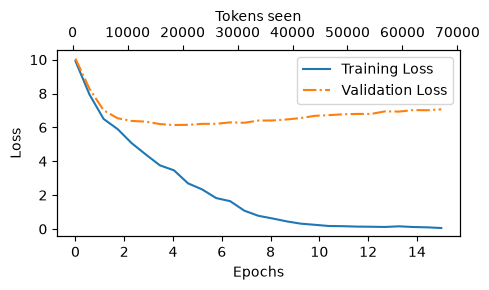

In [144]:
# visualizing val and training loss (why vall stalls )
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen,tokens_seen,train_losses,val_losses):
    fig,ax1=plt.subplots(figsize=(5,3)) # window and viewport
    ax1.plot(epochs_seen,train_losses,label="Training Loss")
    ax1.plot(epochs_seen,val_losses,linestyle="-.",label="Validation Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax2=ax1.twiny()
    ax2.plot(tokens_seen,train_losses,alpha=0) # alligning ticks 
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor=torch.linspace(0,num_epochs,len(train_losses))
plot_losses(epochs_tensor,tokens_seen,train_losses,val_losses)

# Text generation strategies but before that, saving the model weights



In [145]:
# Save only the model weights
torch.save(model.state_dict(), "model_weights.pth")

# loading back
# First, recreate the model architecture
#model = GPT_Model()
# Then load the saved weights
#model.load_state_dict(torch.load("model_weights.pth"))
#model.eval()  # set to evaluation mode



In [146]:
#text generation current
# now testing
model.eval()
text="What is the meaning of life"
token=text_to_token_ids(text,tokenizer).to(device)
model.to(device)
output_tokens=generate_text_simple(model,token,max_new_tokens=15,context_size=GPT_CONFIG_124M["context_length"])
token_ids_to_text(output_tokens,tokenizer)

'What is the meaning of life-closed frame.\nAnd his tone told me in a flash'

In [147]:
# text generation strategies

# previous we used greedy decoding with the highest prob value

# now we will use Top K and Temperature scalling

# first making a dummy vocab to illustrate
vocab={
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8
}

inverse_vocab={v:k for k,v in vocab.items()} # reverse

# assume the LLM is given "every effort moves you" and generates the following logits
next_token_logits=torch.tensor([4.51,0.89,-1.90,6.75,1.63,-1.62,-1.89,6.28,1.79])

# we convert these logits to probabilities using softmax and get the highest val token id using the
# argmax function 
probas=torch.softmax(next_token_logits,dim=-1)
next_token_id=torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

# it prints forward 6.75 one,
# to implement a probabilistic sampling, we replace argmax with multimonial()

torch.manual_seed(123)
next_token_id=torch.multinomial(probas,num_samples=1).item()
print(inverse_vocab[next_token_id])

# simulating 1000 iterations
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample=[torch.multinomial(probas,num_samples=1).item()
            for i in range (1_000)]
    sampled_ids=torch.bincount(torch.tensor(sample))
    for toke_id, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[toke_id]}")

print_sampled_tokens(probas)  



forward
toward
71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you


In [148]:
#Temperateure Scsalling
#it is just logits divided by a temperate variable

# WE can further control this using Temperature scalling
def softmax_with_temperature(logits,temperature):
    scalled_logits=logits/temperature

    return torch.softmax(scalled_logits,dim=0)

scaled_toks=softmax_with_temperature(next_token_logits,0.8)
print_sampled_tokens(scaled_toks)
#next_token_id=torch.multinomial(scaled_toks,num_samples=1).item()
#print(inverse_vocab[next_token_id])
# temperature >1 is more uniform distribution (creative), smaller than 1 is more confident



47 x closer
0 x every
0 x effort
580 x forward
1 x inches
0 x moves
0 x pizza
372 x toward


# now the topK

In [149]:
# Top K approach selects the top models (as per k value) and assigns neg inf to the rest
# this ensures that completely unrelated tokens arent selected while allowing creative generation

top_k=3
top_logits,top_pos=torch.topk(next_token_logits,top_k)
print("Top Logits: ", top_logits)
print("Top Positions: ", top_pos) # in the vocab

# we use python where function to set the logits value to zero that are below the top logits values within
# our topk and set em to neg inf
new_logits=torch.where(condition=next_token_logits<top_logits[-1],# the last of our topk
                    input=torch.tensor(float('-inf')),
                    other=next_token_logits)
print("new logits: ", new_logits)

# now applying softmax to turn into probabilities
topk_porbas=torch.softmax(new_logits,dim=-1)
print(topk_porbas) 
# now our output wont be pizza for the input "every effort moves you"

Top Logits:  tensor([6.7500, 6.2800, 4.5100])
Top Positions:  tensor([3, 7, 0])
new logits:  tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


# Making a new text generation function


In [150]:
def generate_text_pro(model,idx,max_new_tokens,context_size,temperature=None,top_k=None,eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond=idx[:,-context_size:] # only the appkicable context szie is used
        with torch.no_grad():
            logits=model(idx_cond)
        logits=logits[:,-1,]

        if top_k is not None:
            top_logits,_=torch.topk(logits,top_k)
            min_val=top_logits[:,-1]
            logits=torch.where(logits<min_val,
                               torch.tensor(float('-inf')).to(logits.device),
                               logits)

        if temperature>0.0:
            logits=logits/temperature
            probas=torch.softmax(logits,dim=-1)
            idx_next=torch.multinomial(probas,num_samples=1)
        else:
            idx_next=torch.argmax(logits,dim=-1,keepdim=True)
        if idx_next==eos_id:
                break
        idx=torch.cat((idx,idx_next),dim=1)
    return idx

In [152]:
#testing

#text generation current
# now testing
model.eval()
text=" Every effort moves you"
token=text_to_token_ids(text,tokenizer).to(device)
model.to(device)
output_tokens=generate_text_pro(model,token,max_new_tokens=15,context_size=GPT_CONFIG_124M["context_length"],top_k=10,temperature=0.5)
token_ids_to_text(output_tokens,tokenizer)

' Every effort moves you?"\n\n"Yes--quite insensible to the irony. She wanted'